**Set environment**

In [16]:
import numpy  as np
import pandas as pd
import pickle
import os

from Bio import SeqIO

import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
%run ../run_config_project.py
show_env()

BASE DIRECTORY (FD_BASE): /hpc/group/igvf/kk319
REPO DIRECTORY (FD_REPO): /hpc/group/igvf/kk319/repo
WORK DIRECTORY (FD_WORK): /hpc/group/igvf/kk319/work
DATA DIRECTORY (FD_DATA): /hpc/group/igvf/kk319/data


You are working with      IGVF BlueSTARR
PATH OF PROJECT (FD_PRJ): /hpc/group/igvf/kk319/repo/Proj_IGVF_BlueSTARR
PROJECT RESULTS (FD_RES): /hpc/group/igvf/kk319/repo/Proj_IGVF_BlueSTARR/results
PROJECT SCRIPTS (FD_EXE): /hpc/group/igvf/kk319/repo/Proj_IGVF_BlueSTARR/scripts
PROJECT DATA    (FD_DAT): /hpc/group/igvf/kk319/repo/Proj_IGVF_BlueSTARR/data
PROJECT NOTE    (FD_NBK): /hpc/group/igvf/kk319/repo/Proj_IGVF_BlueSTARR/notebooks
PROJECT DOCS    (FD_DOC): /hpc/group/igvf/kk319/repo/Proj_IGVF_BlueSTARR/docs
PROJECT LOG     (FD_LOG): /hpc/group/igvf/kk319/repo/Proj_IGVF_BlueSTARR/log
PROJECT REF     (FD_REF): /hpc/group/igvf/kk319/repo/Proj_IGVF_BlueSTARR/references



## Import data

In [4]:
txt_fdiry = os.path.join(FD_RES, "analysis_variant_motif_richard", "batches_dev")
txt_fpath_ref   = f"{txt_fdiry}/motifscan_variant_closed_gof_bluestarr_flank35_dev1000_ref.pkl"
txt_fpath_obs   = f"{txt_fdiry}/motifscan_variant_closed_gof_bluestarr_flank35_dev1000_obs.pkl"
txt_fpath_unobs = f"{txt_fdiry}/motifscan_variant_closed_gof_bluestarr_flank35_dev1000_unobs.pkl"

with open(txt_fpath_ref, "rb") as file:
    dct_motifscan_ref = pickle.load(file)
    
with open(txt_fpath_obs, "rb") as file:
    dct_motifscan_obs = pickle.load(file)
    
with open(txt_fpath_unobs, "rb") as file:
    dct_motifscan_unobs = pickle.load(file)

In [10]:
### Compare sequence IDs across ref / obs / unobs
set_seq_idx_ref   = set(dct_motifscan_ref.keys())
set_seq_idx_obs   = set(dct_motifscan_obs.keys())
set_seq_idx_unobs = set(dct_motifscan_unobs.keys())

print(f"Number of sequences:")
print(f"  ref:   {len(set_seq_idx_ref)}")
print(f"  obs:   {len(set_seq_idx_obs)}")
print(f"  unobs: {len(set_seq_idx_unobs)}")

if set_seq_idx_ref == set_seq_idx_obs == set_seq_idx_unobs:
    print("All sequence ID sets match across ref / obs / unobs")
else:
    print("Error: Sequence ID mismatch detected")
    print(f"  ref-only:   {len(set_seq_idx_ref - set_seq_idx_obs - set_seq_idx_unobs)}")
    print(f"  obs-only:   {len(set_seq_idx_obs - set_seq_idx_ref - set_seq_idx_unobs)}")
    print(f"  unobs-only: {len(set_seq_idx_unobs - set_seq_idx_ref - set_seq_idx_obs)}")

Number of sequences:
  ref:   1000
  obs:   1000
  unobs: 1000
All sequence ID sets match across ref / obs / unobs


In [14]:
### Compare motif sets for one representative sequence
idx = next(iter(dct_motifscan_ref))
set_motif_idx_ref   = set(dct_motifscan_ref[idx].keys())
set_motif_idx_obs   = set(dct_motifscan_obs[idx].keys())
set_motif_idx_unobs = set(dct_motifscan_unobs[idx].keys())

print(f"Sequence index: {idx}")
print(f"Number of motifs per file:")
print(f"  ref:   {len(set_motif_idx_ref)}")
print(f"  obs:   {len(set_motif_idx_obs)}")
print(f"  unobs: {len(set_motif_idx_unobs)}")

if set_motif_idx_ref == set_motif_idx_obs == set_motif_idx_unobs:
    print("Motif sets match across ref / obs / unobs")
else:
    print("Error: Motif ID mismatch detected")
    print(f"  ref-only:   {len(set_motif_idx_ref - set_motif_idx_obs - set_motif_idx_unobs)}")
    print(f"  obs-only:   {len(set_motif_idx_obs - set_motif_idx_ref - set_motif_idx_unobs)}")
    print(f"  unobs-only: {len(set_motif_idx_unobs - set_motif_idx_ref - set_motif_idx_obs)}")

Sequence index: chr9:135685432:G:G:C
Number of motifs per file:
  ref:   879
  obs:   879
  unobs: 879
Motif sets match across ref / obs / unobs


In [15]:
### init
dct_motifscan_delta   = {}
lst_motifscan_summary = []

# Loop through each sequence
for txt_seq_idx in dct_motifscan_ref.keys():
    
    # retrieve motif ids for each sequence
    vec_txt_motif_idx = dct_motifscan_ref[txt_seq_idx].keys()
    dct_results = {}
    
    # loop through each motif
    for txt_motif_idx in vec_txt_motif_idx:

        # extract score arrays for each direction
        arr_score_fwd_obs   = dct_motifscan_obs[txt_seq_idx][txt_motif_idx]["forward"]
        arr_score_fwd_unobs = dct_motifscan_unobs[txt_seq_idx][txt_motif_idx]["forward"]
        arr_score_rev_obs   = dct_motifscan_obs[txt_seq_idx][txt_motif_idx]["reverse"]
        arr_score_rev_unobs = dct_motifscan_unobs[txt_seq_idx][txt_motif_idx]["reverse"]

        # strand-wise delta (unobs - obs)
        arr_delta_fwd = arr_score_fwd_unobs - arr_score_fwd_obs
        arr_delta_rev = arr_score_rev_unobs - arr_score_rev_obs

        # merge strands (strand-agnostic maximum)
        arr_delta_max = np.maximum(arr_delta_fwd, arr_delta_rev)

        # collect the delta arrays
        dct_results[txt_motif_idx] = {
            "forward": arr_delta_fwd,
            "reverse": arr_delta_rev,
            "merge":   arr_delta_max
        }
        
        # summarize the deltas
        dct_summary = {
            "seq_id":       txt_seq_idx,
            "motif_id":     txt_motif_idx,
            "fwd_max":      np.nanmax(arr_delta_fwd),
            "fwd_mean":     np.nanmean(arr_delta_fwd),
            "fwd_median":   np.nanmedian(arr_delta_fwd),
            "rev_max":      np.nanmax(arr_delta_rev),
            "rev_mean":     np.nanmean(arr_delta_rev),
            "rev_median":   np.nanmedian(arr_delta_rev),
            "merge_max":    np.nanmax(arr_delta_max),
            "merge_mean":   np.nanmean(arr_delta_max),
            "merge_median": np.nanmedian(arr_delta_max),
            
        }
        lst_motifscan_summary.append(dct_summary)
        
    # store the per-sequence deltas
    dct_motifscan_delta[txt_seq_idx] = dct_results

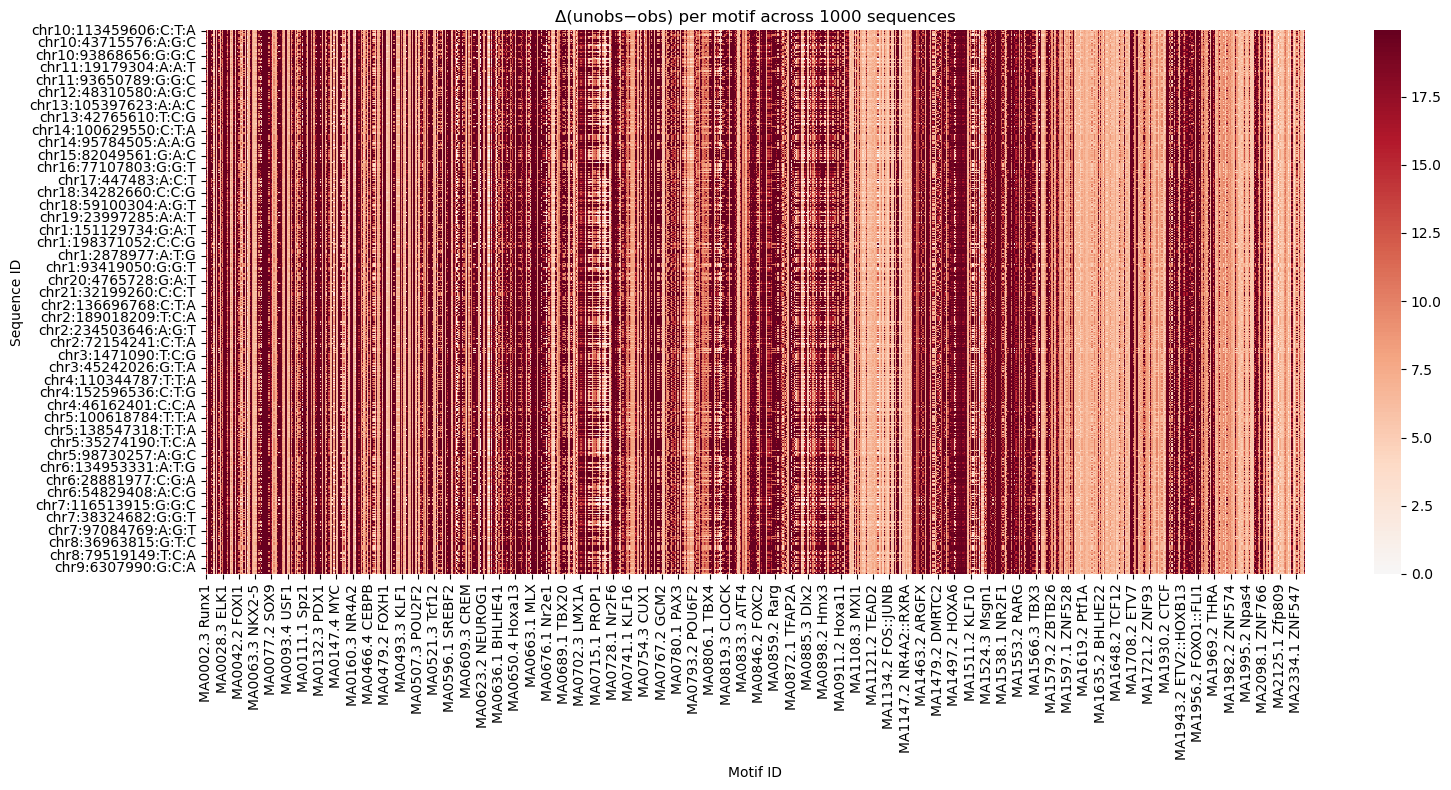

In [20]:
dat_summary = pd.DataFrame(lst_motifscan_summary)

# Pivot to sequence × motif matrix using merge_max
mat_heatmap = dat_summary.pivot(index="seq_id", columns="motif_id", values="merge_max")

plt.figure(figsize=(16,8))
sns.heatmap(mat_heatmap, cmap="RdBu_r", center=0)
plt.title("Δ(unobs−obs) per motif across 1000 sequences")
plt.xlabel("Motif ID")
plt.ylabel("Sequence ID")
plt.tight_layout()
plt.show()

In [18]:
mat_heatmap.shape

(1000, 879)

In [21]:
dat_summary.shape

(879000, 11)

In [22]:
dat_summary.head()

,seq_id,motif_id,fwd_max,fwd_mean,fwd_median,rev_max,rev_mean,rev_median,merge_max,merge_mean,merge_median
0,chr9:135685432:G:G:C,MA0002.3 Runx1,2.846921,-0.567838,0.0,19.922160,0.567838,0.0,19.922160,0.630561,0.0
1,chr9:135685432:G:G:C,MA0003.5 TFAP2A,6.356318,0.051759,0.0,6.152052,-0.051759,0.0,6.356318,0.062752,0.0
2,chr9:135685432:G:G:C,MA0004.1 Arnt,19.931569,-0.241387,0.0,19.931569,0.241387,0.0,19.931569,0.241387,0.0
3,chr9:135685432:G:G:C,MA0006.2 Ahr::Arnt,19.870168,-0.594056,0.0,19.931569,0.594056,0.0,19.931569,1.187195,0.0
4,chr9:135685432:G:G:C,MA0007.4 Ar,19.921611,0.159668,0.0,19.926315,-0.159668,0.0,19.926315,1.465424,0.0


In [24]:
# set output directory
txt_fdiry = os.path.join(FD_RES, "analysis_variant_motif_richard", "batches_dev")
txt_fpath_out_score   = f"{txt_fdiry}/motifscan_variant_closed_gof_bluestarr_flank35_dev1000_delta_score.pkl"
txt_fpath_out_summary = f"{txt_fdiry}/motifscan_variant_closed_gof_bluestarr_flank35_dev1000_delta_summary.tsv"

with open(txt_fpath_out_score, "wb") as file:
    pickle.dump(dct_motifscan_delta, file)
print("Saved:", txt_fpath_out_score)

dat_summary = pd.DataFrame(lst_motifscan_summary)
dat_summary.to_csv(txt_fpath_out_summary, sep="\t", index=False)
print("Saved:", txt_fpath_out_summary)

Saved: /hpc/group/igvf/kk319/repo/Proj_IGVF_BlueSTARR/results/analysis_variant_motif_richard/batches_dev/motifscan_variant_closed_gof_bluestarr_flank35_dev1000_delta_score.pkl
Saved: /hpc/group/igvf/kk319/repo/Proj_IGVF_BlueSTARR/results/analysis_variant_motif_richard/batches_dev/motifscan_variant_closed_gof_bluestarr_flank35_dev1000_delta_summary.tsv
